In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from IPython.display import display
import ipywidgets as widgets

# 1. SETTINGS & DEVICE

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
history = {'train_loss': [], 'val_acc': [], 'train_acc': []}

# 2. DATA PIPELINE (CenterCrop & Augmentation)

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

root = "/kaggle/input/datasets/tanjemahamed/odir5k-classification/datasets"
full_dataset = datasets.ImageFolder(root=root, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)

train_size = int(0.85 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# 3. MODEL: EFFICIENTNET-B0 

In [4]:
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Roadmap: Unfreeze deeper feature blocks (Block 6+)
for param in model.parameters():
    param.requires_grad = False
for param in model.features[6:].parameters():
    param.requires_grad = True

num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(512, num_classes)
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]


# 4. LOSS & OPTIMIZER (Weighted Multi-Label)

In [5]:
targets = [label for _, label in full_dataset]
class_counts = Counter(targets)
weights = torch.tensor([len(targets) / class_counts[i] for i in range(num_classes)]).float().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights) 

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

# 5. EXPLAINABLE AI (Grad-CAM)

In [6]:
def get_gradcam(model, input_tensor, target_layer):
    gradients, activations = [], []
    def backward_hook(module, grad_in, grad_out): gradients.append(grad_out[0])
    def forward_hook(module, input, output): activations.append(output)

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.eval()
    logits = model(input_tensor.to(device))
    pred_idx = logits.argmax(dim=1)
    model.zero_grad()
    logits[0, pred_idx].backward()

    grads = gradients[0].cpu().data.numpy()[0]
    acts = activations[0].cpu().data.numpy()[0]
    weights_cam = np.mean(grads, axis=(1, 2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights_cam): cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-7)
    h1.remove(); h2.remove()
    return cam, pred_idx.item()

# 6. RESEARCH EVALUATION (Graphs & Metrics)

In [7]:
def run_research_evaluation():
    # 1. Plot Learning Curves
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Accuracy Curves'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], color='red')
    plt.title('Training Loss Curve'); plt.show()

    # 2. Confusion Matrix & F1-Scores
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images.to(device))
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\n[RESEARCH REPORT: CLASSIFICATION METRICS]")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()

# 7. TRAINING & EXECUTION

In [8]:
def train_model(epochs=30):
    best_acc = 0.0
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            labels_oh = torch.nn.functional.one_hot(labels, num_classes).float()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_oh)
            loss.backward(); optimizer.step()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        # Validation
        model.eval(); val_correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                val_correct += (model(images.to(device)).argmax(1) == labels.to(device)).sum().item()
        
        val_acc = 100 * val_correct / len(val_dataset)
        history['train_loss'].append(running_loss/len(train_loader))
        history['train_acc'].append(100 * correct/total)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_acc)
        print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_eye_model.pth")

# 8. DIAGNOSTIC INTERFACE (Predict + XAI)

Epoch 1 | Loss: 1.0749 | Val Acc: 44.53%
Epoch 2 | Loss: 0.8237 | Val Acc: 50.78%
Epoch 3 | Loss: 0.6952 | Val Acc: 45.26%
Epoch 4 | Loss: 0.5887 | Val Acc: 50.89%
Epoch 5 | Loss: 0.5103 | Val Acc: 51.30%
Epoch 6 | Loss: 0.4479 | Val Acc: 55.58%
Epoch 7 | Loss: 0.4168 | Val Acc: 54.95%
Epoch 8 | Loss: 0.3534 | Val Acc: 57.46%
Epoch 9 | Loss: 0.3292 | Val Acc: 57.98%
Epoch 10 | Loss: 0.2823 | Val Acc: 57.66%
Epoch 11 | Loss: 0.2720 | Val Acc: 60.27%
Epoch 12 | Loss: 0.2306 | Val Acc: 58.39%
Epoch 13 | Loss: 0.2055 | Val Acc: 58.19%
Epoch 14 | Loss: 0.1808 | Val Acc: 59.96%
Epoch 15 | Loss: 0.1689 | Val Acc: 60.38%
Epoch 16 | Loss: 0.1500 | Val Acc: 59.44%
Epoch 17 | Loss: 0.1370 | Val Acc: 60.38%
Epoch 18 | Loss: 0.1191 | Val Acc: 60.79%
Epoch 19 | Loss: 0.1130 | Val Acc: 60.79%
Epoch 20 | Loss: 0.0988 | Val Acc: 60.69%
Epoch 21 | Loss: 0.0924 | Val Acc: 60.06%
Epoch 22 | Loss: 0.0940 | Val Acc: 61.42%
Epoch 23 | Loss: 0.0833 | Val Acc: 62.46%
Epoch 24 | Loss: 0.0939 | Val Acc: 58.92%
E

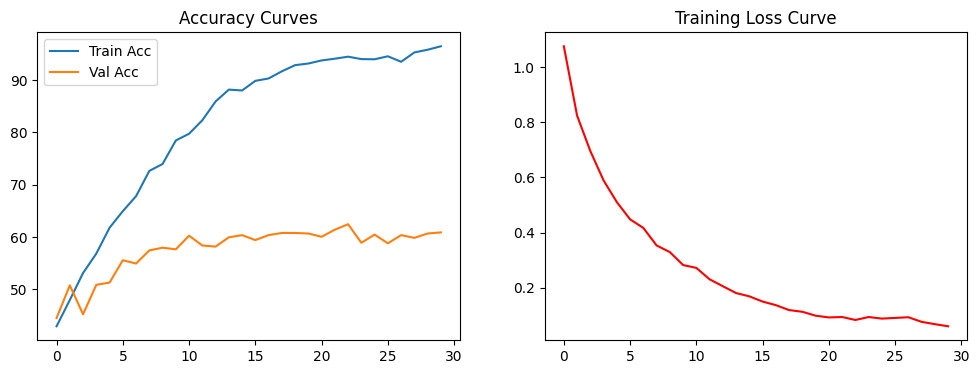


[RESEARCH REPORT: CLASSIFICATION METRICS]
                 precision    recall  f1-score   support

ageDegeneration       0.60      0.48      0.53        44
       cataract       0.80      0.92      0.85        48
       diabetes       0.50      0.52      0.51       216
       glaucoma       0.38      0.35      0.36        46
   hypertension       0.45      0.22      0.29        23
         myopia       0.74      0.90      0.81        29
         normal       0.68      0.75      0.71       438
         others       0.44      0.29      0.35       115

       accuracy                           0.61       959
      macro avg       0.57      0.55      0.55       959
   weighted avg       0.59      0.61      0.60       959



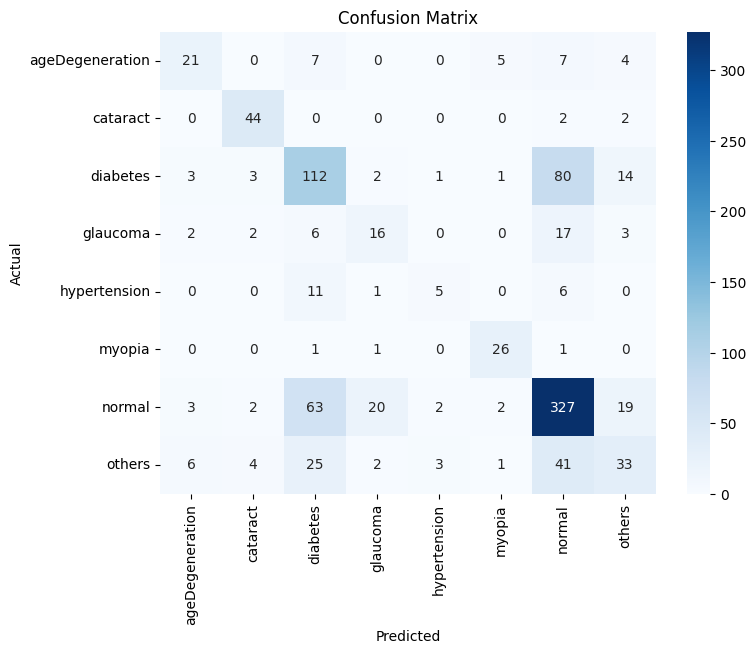

In [9]:
def predict_and_explain(image_path):
    img_pil = Image.open(image_path).convert("RGB")
    input_tensor = test_transform(img_pil).unsqueeze(0)
    heatmap, pred_idx = get_gradcam(model, input_tensor, model.features[-1])

    img_cv = cv2.cvtColor(np.array(img_pil.resize((224, 224))), cv2.COLOR_RGB2BGR)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlayed = cv2.addWeighted(img_cv, 0.6, heatmap_colored, 0.4, 0)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(img_pil); plt.title("Original Fundus"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB))
    plt.title(f"XAI Diagnosis: {class_names[pred_idx]}"); plt.axis('off'); plt.show()

# Run Pipeline
train_model(epochs=30)
run_research_evaluation()



# Launch UI

In [10]:
upload = widgets.FileUpload(accept='image/*', multiple=False)
output_area = widgets.Output()
display(upload, output_area)

def on_upload_change(change):
    with output_area:
        output_area.clear_output()
        if not upload.value: return
        with open("temp.jpg", "wb") as f: f.write(upload.value[0]['content'])
        predict_and_explain("temp.jpg")

upload.observe(on_upload_change, names='value')

FileUpload(value=(), accept='image/*', description='Upload')

Output()